<a href="https://colab.research.google.com/github/dithakedhi/double_speed_reducer/blob/main/Copy_of_Tugas4_255314097.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tugas Perbandingan K-means, Hierarchical, DBSCAN
Bandingkan ketiga algoritma clustering  K-means, Hierarchical, DBSCAN, beri penjelasan per-cell, dan tambahkan penjelasan code. DIdalamnyanya berisi:
1. Read Dataset

2. Exploration Data Analysis (EDA)

3. Preprocessing (Bandingkan boxplot untuk dataset sebelum dan sesudah di normalisasi/standarisasi)

4. Implementasi Model (K-Means, Heirarchical, DBScan)

5. Buat plot untuk hasil tiap model


Buatkan kesimpulan dari ketika algoritma, mana yang lebih baik untuk dataset Heart Failure ini.

Kirim berupa file ipynb (Tugas4_NIM)



In [ ]:
#1.READ DATASET
# Menghubungkan Google Colab dengan file dari komputer
from google.colab import files
import pandas as pd

# Upload dataset
uploaded = files.upload()

# Membaca dataset
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# Menampilkan 5 data pertama
df.head()

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset.csv


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Penjelasan cell

Cell ini digunakan untuk memasukkan dataset Heart Failure dari komputer ke Google Colab. files.upload() akan menampilkan pilihan untuk memilih file dari komputer. Setelah file berhasil di-upload, pd.read_csv() digunakan untuk membaca file CSV dan menyimpannya ke dalam variabel df. Perintah df.head() digunakan untuk menampilkan lima data pertama dari dataset.

In [ ]:
#2. Exploration Data Analysis (EDA)

# Melihat jumlah baris dan kolom
print("Jumlah baris dan kolom:", df.shape)

# Melihat informasi dataset
print("\nInformasi dataset:")
df.info()

# Melihat statistik deskriptif
print("\nStatistik deskriptif:")
display(df.describe())

# Mengecek missing value
print("\nJumlah missing value:")
print(df.isnull().sum())

Jumlah baris dan kolom: (299, 13)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000



Jumlah missing value:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


Penjelasan cell

Cell ini digunakan untuk mengetahui kondisi awal dataset. df.shape digunakan untuk melihat jumlah baris dan kolom. df.info() digunakan untuk melihat nama kolom, tipe data, dan jumlah data pada setiap kolom. df.describe() digunakan untuk melihat statistik seperti rata-rata, nilai minimum, maksimum, dan standar deviasi. Sedangkan df.isnull().sum() digunakan untuk mengecek apakah terdapat data kosong pada setiap kolom.

Pada dataset Heart Failure terdapat 299 baris dan 13 kolom. Hasil pengecekan juga menunjukkan bahwa tidak terdapat missing value.

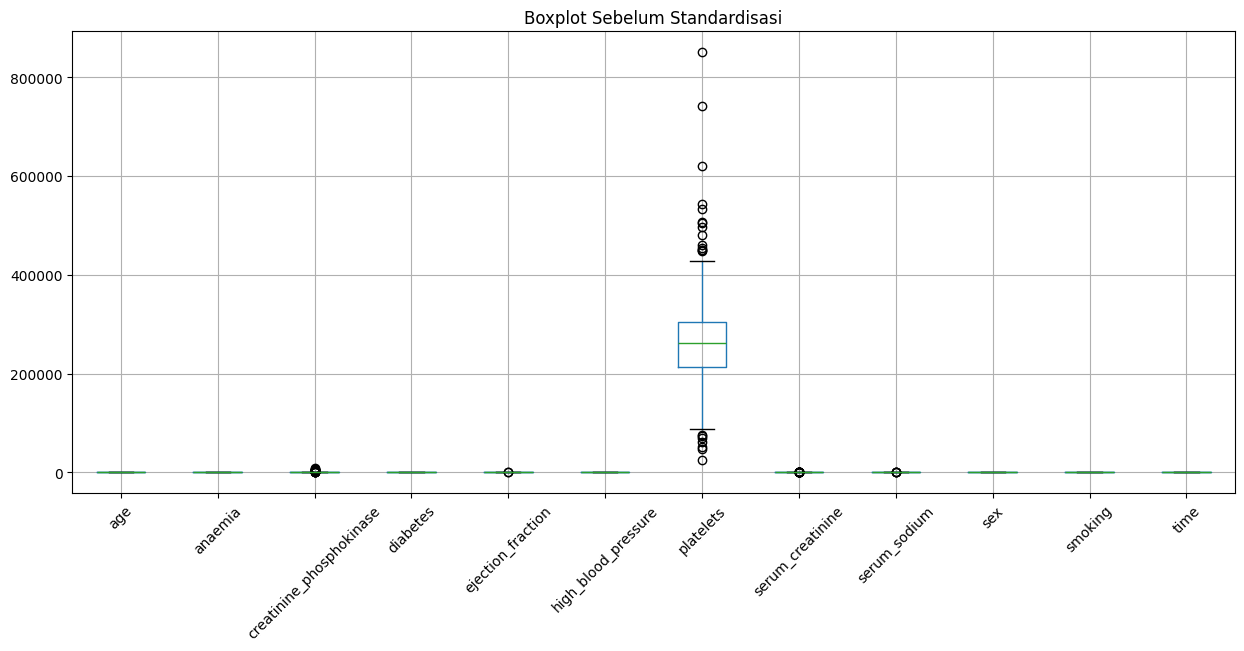

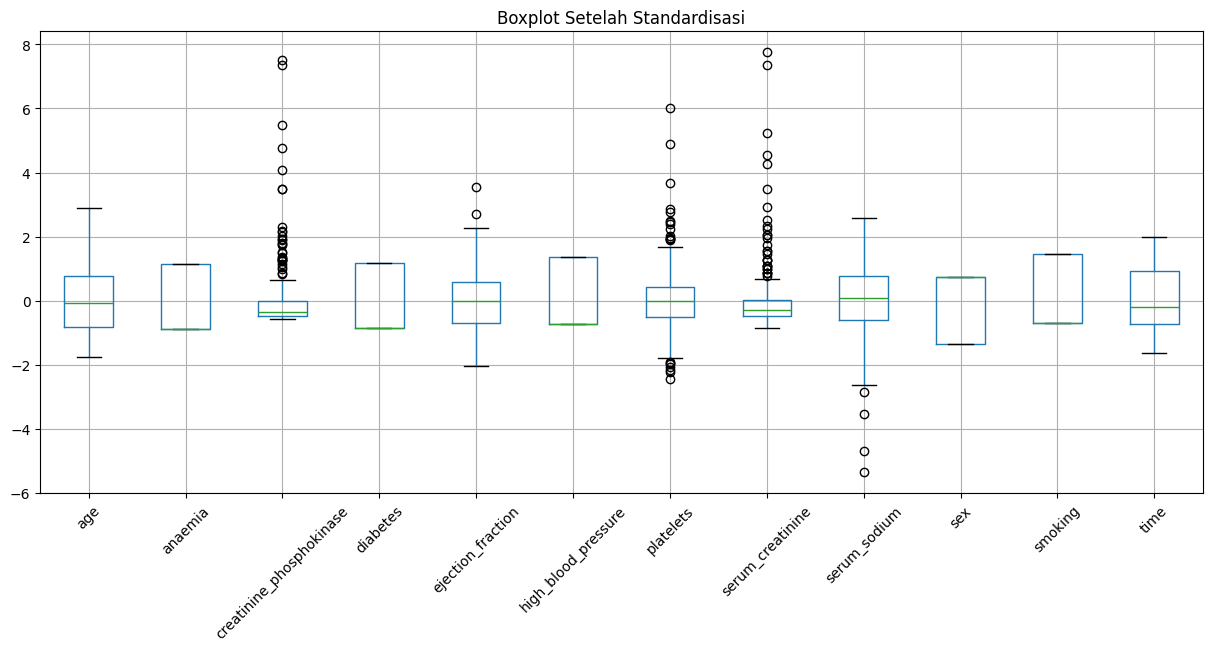

In [ ]:
#3. Preprocessing

"""
Pada preprocessing, DEATH_EVENT tidak digunakan karena merupakan target.
Setelah itu data akan dibandingkan menggunakan
boxplot sebelum dan sesudah standardisasi.
"""
# Import library
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Memisahkan fitur dari target
X = df.drop("DEATH_EVENT", axis=1)

# Boxplot sebelum standardisasi
plt.figure(figsize=(15, 6))
X.boxplot()

plt.title("Boxplot Sebelum Standardisasi")
plt.xticks(rotation=45)
plt.show()

# Melakukan standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mengubah hasil standardisasi menjadi DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Boxplot setelah standardisasi
plt.figure(figsize=(15, 6))
X_scaled.boxplot()

plt.title("Boxplot Setelah Standardisasi")
plt.xticks(rotation=45)
plt.show()

Penjelasan Cell

Cell ini digunakan untuk mempersiapkan data sebelum dilakukan proses clustering. Pertama, kolom DEATH_EVENT dihapus karena kolom tersebut merupakan target, sedangkan pada clustering kita hanya menggunakan atribut sebagai data input.

Selanjutnya dibuat boxplot sebelum standardisasi untuk melihat persebaran data dan perbedaan skala pada setiap atribut. Karena beberapa atribut memiliki rentang nilai yang berbeda jauh, data kemudian dilakukan standardisasi menggunakan StandardScaler.

Setelah standardisasi, data diubah kembali menjadi DataFrame agar nama kolom tetap sama seperti data awal. Kemudian dibuat boxplot kedua untuk melihat kondisi data setelah standardisasi.

Dari kedua boxplot tersebut dapat dilihat bahwa setelah standardisasi, skala setiap atribut menjadi lebih seimbang. Hal ini penting karena K-Means, Hierarchical, dan DBSCAN menggunakan perhitungan jarak dalam menentukan kelompok data. Dengan skala yang sudah disamakan, atribut dengan nilai yang besar tidak terlalu mendominasi proses clustering.

In [ ]:
"""
4. Implementasi Model

Pada bagian ini ketiga algoritma yang diminta pada soal digunakan,
yaitu K-Means, Hierarchical, dan DBSCAN.from sklearn.cluster import KMeans

"""

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# K-MEANS
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

# HIERARCHICAL
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)


# DBSCAN
dbscan = DBSCAN(
    eps=2.9,
    min_samples=3
)

dbscan_labels = dbscan.fit_predict(X_scaled)

# Mengabaikan data noise (-1)
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
else:
    dbscan_score = None


# Menampilkan hasil
print("HASIL CLUSTERING")
print("========================")

print("K-Means")
print("Silhouette Score:", round(kmeans_score, 4))

print("\nHierarchical")
print("Silhouette Score:", round(hierarchical_score, 4))

print("\nDBSCAN")
print("Silhouette Score:", round(dbscan_score, 4))

print("\nJumlah data pada cluster DBSCAN:")
print(pd.Series(dbscan_labels).value_counts())

HASIL CLUSTERING
K-Means
Silhouette Score: 0.1179

Hierarchical
Silhouette Score: 0.1051

DBSCAN
Silhouette Score: 0.2933

Jumlah data pada cluster DBSCAN:
 0    276
-1     19
 1      4
Name: count, dtype: int64


Penjelasan cell

Cell ini digunakan untuk menerapkan tiga algoritma clustering pada data yang sudah distandarisasi.

K-Means digunakan untuk membagi data menjadi dua cluster berdasarkan jarak data terhadap pusat cluster. Hierarchical menggunakan metode agglomerative dengan empat cluster dan linkage="ward". Sedangkan DBSCAN menggunakan parameter eps dan min_samples untuk menentukan kelompok berdasarkan kepadatan data.

Selain melakukan clustering, cell ini juga menghitung Silhouette Score untuk mengetahui kualitas hasil pengelompokan. Nilai Silhouette Score yang semakin mendekati 1 menunjukkan bahwa pemisahan antar cluster semakin jelas.

Pada dataset ini diperoleh hasil:

K-Means = 0,1179

Hierarchical = 0,1051

DBSCAN = 0,2933

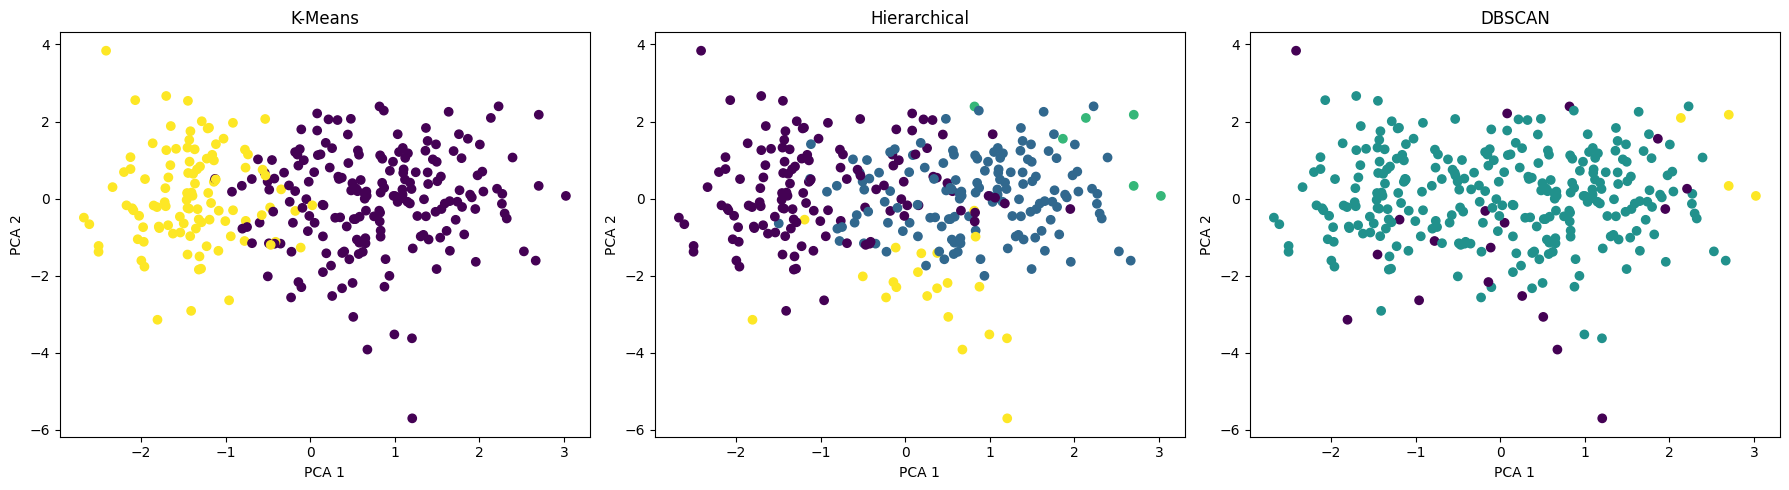

In [ ]:
"""
5. Plot Hasil Masing-Masing Model
Karena dataset mempunyai banyak atribut,
digunakan PCA untuk mengubah data menjadi dua dimensi
sehingga hasil clustering dapat divisualisasikan.
from sklearn.decomposition import PCA
"""
# Mengubah data menjadi 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Membuat visualisasi ketiga metode
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels
)

axes[0].set_title("K-Means")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")


# Hierarchical
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels
)

axes[1].set_title("Hierarchical")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")


# DBSCAN
axes[2].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels
)

axes[2].set_title("DBSCAN")
axes[2].set_xlabel("PCA 1")
axes[2].set_ylabel("PCA 2")


plt.tight_layout()
plt.show()

Penjelasan cell

Cell ini digunakan untuk melihat hasil clustering dari ketiga metode dalam bentuk grafik. PCA digunakan untuk mengurangi banyak atribut menjadi dua komponen utama, yaitu PCA 1 dan PCA 2.

Grafik pertama menunjukkan hasil K-Means, grafik kedua menunjukkan hasil Hierarchical, dan grafik ketiga menunjukkan hasil DBSCAN. Perbedaan warna pada masing-masing grafik menunjukkan cluster yang terbentuk.

Pada DBSCAN, data dengan label -1 menunjukkan data yang dianggap sebagai noise.

,Metode,Silhouette Score
0,K-Means,0.117851
1,Hierarchical,0.105056
2,DBSCAN,0.293278


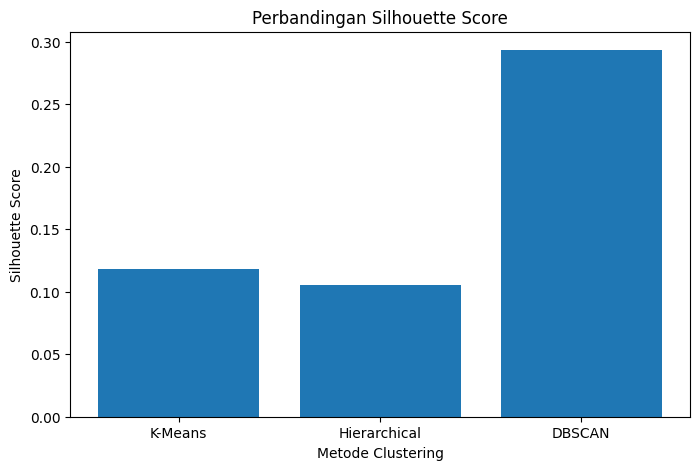

In [ ]:
#6. Perbandingan Hasil Ketiga Algoritma
# Membuat tabel perbandingan
hasil = pd.DataFrame({
    "Metode": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score,
        dbscan_score
    ]
})

# Menampilkan tabel
display(hasil)

# Membuat grafik perbandingan
plt.figure(figsize=(8, 5))

plt.bar(
    hasil["Metode"],
    hasil["Silhouette Score"]
)

plt.title("Perbandingan Silhouette Score")
plt.xlabel("Metode Clustering")
plt.ylabel("Silhouette Score")

plt.show()

Penjelasan cell

Cell ini digunakan untuk membandingkan hasil ketiga algoritma berdasarkan nilai Silhouette Score. Hasilnya dimasukkan ke dalam tabel agar lebih mudah dibandingkan, kemudian ditampilkan dalam bentuk grafik.

7. Kesimpulan
Penjelasan

Berdasarkan hasil perbandingan K-Means, Hierarchical Clustering, dan DBSCAN pada dataset Heart Failure, ketiga algoritma menghasilkan pembagian cluster yang berbeda. K-Means memperoleh Silhouette Score sebesar 0,1179, Hierarchical memperoleh 0,1051, sedangkan DBSCAN memperoleh 0,2933.

Berdasarkan nilai Silhouette Score, DBSCAN menghasilkan nilai paling tinggi pada percobaan ini. Hal tersebut menunjukkan bahwa pemisahan cluster yang dihasilkan DBSCAN lebih jelas berdasarkan metrik tersebut. Namun, DBSCAN juga menghasilkan beberapa data yang dianggap sebagai noise, sehingga hasilnya perlu diperhatikan ketika melakukan interpretasi.

K-Means memiliki proses yang lebih sederhana karena jumlah cluster ditentukan terlebih dahulu. Hierarchical melakukan pengelompokan secara bertahap berdasarkan jarak antar data. Sementara itu, DBSCAN mengelompokkan data berdasarkan kepadatan dan dapat mendeteksi data yang dianggap sebagai noise.

Jadi, berdasarkan hasil pengujian pada dataset Heart Failure dan nilai Silhouette Score, DBSCAN menghasilkan nilai evaluasi tertinggi dalam percobaan ini.